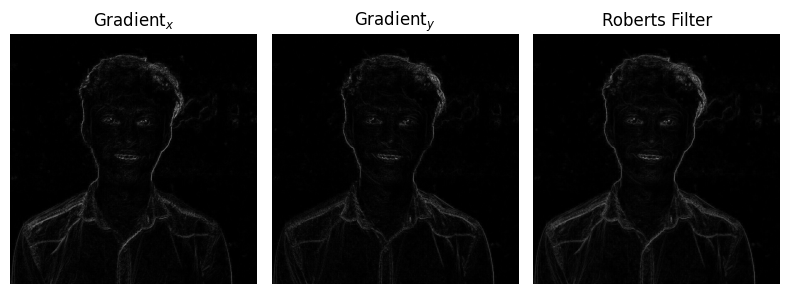

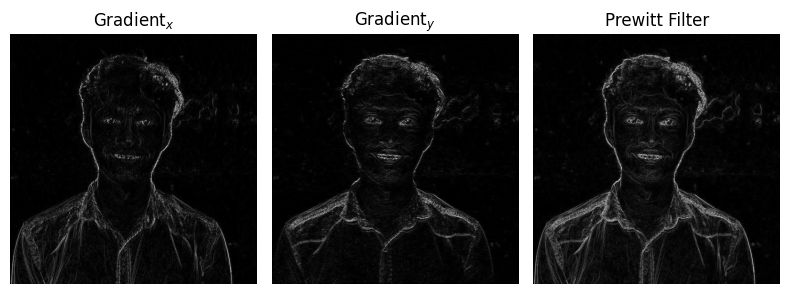

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


img = cv2.imread(r'C:\Users\JAI\Downloads\Ezhil.jpg', cv2.IMREAD_GRAYSCALE)

def show_img(images, titles):
    n = len(images)
    fig, ax = plt.subplots(1, n, figsize=(8, 8))
    
    for i, axx in enumerate(ax):
        axx.imshow(images[i], cmap='gray') 
        axx.set_title(titles[i])
        axx.axis("off")

    plt.tight_layout()
    plt.show()  


def robert_filter(img):
    rob_x = np.array([[1, 0], [0, -1]])
    rob_y = np.array([[0, 1], [-1, 0]])
    
    grad_x = cv2.filter2D(img, cv2.CV_64F, rob_x)
    grad_y = cv2.filter2D(img, cv2.CV_64F, rob_y)
    
    robert_filt = np.sqrt(np.square(grad_x) + np.square(grad_y))
    
    return np.abs(grad_x).astype(np.uint8), np.abs(grad_y).astype(np.uint8), np.uint8(robert_filt)

grad_x, grad_y, res = robert_filter(img)
show_img([grad_x, grad_y, res], ["Gradient$_x$", "Gradient$_y$", "Roberts Filter"])

# Prewitt Filter
def prewitt_filter(img):
    pr_x = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])
    pr_y = np.array([[-1, -1, -1], [0, 0, 0], [1, 1, 1]])
    
    grad_x = cv2.filter2D(img, cv2.CV_64F, pr_x)
    grad_y = cv2.filter2D(img, cv2.CV_64F, pr_y)
    
    prewitt_filt = np.sqrt(np.square(grad_x) + np.square(grad_y))
    
    return np.abs(grad_x).astype(np.uint8), np.abs(grad_y).astype(np.uint8), np.uint8(prewitt_filt)

grad_x, grad_y, res = prewitt_filter(img)
show_img([grad_x, grad_y, res], ["Gradient$_x$", "Gradient$_y$", "Prewitt Filter"])